# Financial Inclusion & Poverty — Pipeline Workflow Notebook
## Snakemake Workflow · Run-All Script · Reproducibility Documentation

**Datasets:** World Bank PIP · Global Findex 2025

**Research Questions:**
- Does bank account ownership correlate with lower poverty headcount rates?
- Does mobile/digital financial access predict poverty reduction over time?
- Which countries represent the best and worst cases for digital financial inclusion relative to poverty?

---
This notebook does three things:

1. **Writes `Snakefile`** — automates the full pipeline from cleaning → merging → analysis
2. **Writes `run_pipeline.py`** — a single command to re-execute the entire workflow
3. **Documents** every step required to repeat the analysis from scratch

> **How to use:** Run all cells top to bottom from the project root directory.  
> Then open a terminal and run `python run_pipeline.py`.


---
## Section 1 — Prerequisites & Environment Check

Run the cell below to verify all required packages and Snakemake are available.


In [1]:
import subprocess
import sys
import os

required = ["pandas", "numpy", "statsmodels", "matplotlib", "snakemake"]
print("Checking required packages...\n")
all_ok = True
for pkg in required:
    try:
        __import__(pkg)
        print(f"  OK   {pkg}")
    except ImportError:
        print(f"  MISSING  {pkg}")
        all_ok = False

if all_ok:
    print("\nAll packages present. Ready to run the pipeline.")
else:
    print("\nInstall missing packages:")
    print("  pip install pandas numpy statsmodels matplotlib snakemake")
    print("  -- or --")
    print("  conda env create -f environment.yml && conda activate findex-pip-analysis")


Checking required packages...

  OK   pandas
  OK   numpy
  OK   statsmodels
  OK   matplotlib
  OK   snakemake

All packages present. Ready to run the pipeline.


### Expected project structure

All commands assume you are running from the **project root** — the top-level folder
containing `data/`, `scripts/`, and `output/`.

```
project/
├── data/
│   ├── raw/
│   │   ├── pip_dataset.csv
│   │   └── GlobalFindexDataset2025.csv
│   └── processed/               <- generated by pipeline
├── scripts/
│   ├── pip2024cleaning.py
│   ├── findex2024cleaning.py
│   ├── findex_cleaning_timeseries.py
│   ├── 2024merging.py
│   ├── merged_2024_analysis.py
│   └── merged_timeseries_analysis.py
├── output/                      <- generated by pipeline
├── Snakefile                    <- written by Section 2
├── run_pipeline.py              <- written by Section 3
└── environment.yml
```

Run the cell below to confirm directories and raw data files exist.


In [2]:
dirs  = ["data/raw", "data/processed", "scripts", "output"]
files = [
    "data/raw/pip_dataset.csv",
    "data/raw/GlobalFindexDatabase2025.csv",
    "scripts/pip2024cleaning.py",
    "scripts/findex2024cleaning.py",
    "scripts/findex_cleaning_timeseries.py",
    "scripts/2024merging.py",
    "scripts/merged_2024_analysis.py",
    "scripts/merged_timeseries_analysis.py",
]

print("Directories:")
for d in dirs:
    tag = "OK" if os.path.isdir(d) else "MISSING — create this folder"
    print(f"  {tag:<8} {d}/")

print("\nRequired files:")
for f in files:
    tag = "OK" if os.path.isfile(f) else "MISSING"
    print(f"  {tag:<8} {f}")


Directories:
  OK       data/raw/
  OK       data/processed/
  OK       scripts/
  OK       output/

Required files:
  OK       data/raw/pip_dataset.csv
  OK       data/raw/GlobalFindexDatabase2025.csv
  OK       scripts/pip2024cleaning.py
  OK       scripts/findex2024cleaning.py
  OK       scripts/findex_cleaning_timeseries.py
  OK       scripts/2024merging.py
  OK       scripts/merged_2024_analysis.py
  OK       scripts/merged_timeseries_analysis.py


---
## Section 2 — Snakemake Workflow

The cell below writes the `Snakefile` to your project root.

### How Snakemake works
Snakemake reads the final outputs declared in `rule all` and works **backwards**
through the dependency graph to determine which rules must run and in what order.
Each rule declares `input:`, `output:`, and `shell:`. If an output already exists
and is newer than its inputs, Snakemake skips that rule automatically.

### Pipeline dependency graph
```
data/raw/pip_dataset.csv        data/raw/GlobalFindexDataset2025.csv
         |                              |                   |
         v                              v                   v
    [clean_pip]            [clean_findex_2024]  [clean_findex_timeseries]
         |                              |                   |
  pip_cleaned_2024.csv    findex_cleaned_2024.csv  findex_cleaned_timeseries.csv
  pip_cleaned_timeseries.csv       |                        |
         |                         +------------------------+
         +---------------------------+
                                     |
                             [merge_datasets]
                            /                 \
              master_dataset_2024.csv   master_timeseries_dataset.csv
                       |                              |
                [analyze_2024]             [analyze_timeseries]
                       |                              |
                 output/*.png                   output/*.png
```


In [10]:
import os

# Corrected Snakefile content - no docstrings inside f-strings

snakefile_content_detailed = '''# =============================================================================
# Snakefile - Financial Inclusion & Poverty End-to-End Pipeline
# =============================================================================
# Detailed DAG with separate branches for each dataset and analysis type
# =============================================================================

rule all:
    input:
        # 2024 Cross-sectional analysis outputs
        "output/BankOwnership-Poverty2024Scatter.png",
        "output/MobileAccount-Poverty2024Scatter.png",
        "output/DigitalOwnership-Poverty2024Scatter.png",
        "output/DigitalAccess-Poverty2024Comparison.png",
        # Timeseries analysis outputs
        "output/TimeseriesGlobalTrendsPlot.png",
        "output/AveragedTimeseriesFinancialAccess-PovertyComparison.png",
        # Statistical outputs
        "output/correlation_analysis.csv",
        "output/regression_results.txt"


# =============================================================================
# PIP DATASET BRANCH - World Bank Poverty data
# =============================================================================

rule clean_pip_2024:
    input:
        pip_raw = "data/raw/pip_dataset.csv"
    output:
        pip_2024 = "data/processed/pip_cleaned_2024.csv"
    shell:
        "cd scripts && python pip2024cleaning.py --year 2024 --output ../data/processed/pip_cleaned_2024.csv"


rule clean_pip_timeseries:
    input:
        pip_raw = "data/raw/pip_dataset.csv"
    output:
        pip_ts = "data/processed/pip_cleaned_timeseries.csv"
    shell:
        "cd scripts && python pip2024cleaning.py --timeseries --output ../data/processed/pip_cleaned_timeseries.csv"


# =============================================================================
# FININDEX DATASET BRANCH - Global Findex financial inclusion data
# =============================================================================

rule clean_findex_2024:
    input:
        findex_raw = "data/raw/GlobalFindexDataset2025.csv"
    output:
        findex_2024 = "data/processed/findex_cleaned_2024.csv"
    shell:
        "cd scripts && python findex2024cleaning.py --year 2024 --output ../data/processed/findex_cleaned_2024.csv"


rule clean_findex_timeseries:
    input:
        findex_raw = "data/raw/GlobalFindexDataset2025.csv"
    output:
        findex_ts = "data/processed/findex_cleaned_timeseries.csv"
    shell:
        "cd scripts && python findex_cleaning_timeseries.py --output ../data/processed/findex_cleaned_timeseries.csv"


# =============================================================================
# MERGING STAGE - Combine PIP and Findex datasets
# =============================================================================

rule merge_2024_cross_sectional:
    input:
        pip_2024 = "data/processed/pip_cleaned_2024.csv",
        findex_2024 = "data/processed/findex_cleaned_2024.csv"
    output:
        master_2024 = "data/processed/master_dataset_2024.csv"
    shell:
        "cd scripts && python 2024merging.py --cross-sectional --output ../data/processed/master_dataset_2024.csv"


rule merge_timeseries:
    input:
        pip_ts = "data/processed/pip_cleaned_timeseries.csv",
        findex_ts = "data/processed/findex_cleaned_timeseries.csv"
    output:
        master_ts = "data/processed/master_timeseries_dataset.csv"
    shell:
        "cd scripts && python 2024merging.py --timeseries --output ../data/processed/master_timeseries_dataset.csv"


# =============================================================================
# ANALYSIS - 2024 Cross-sectional
# =============================================================================

rule analyze_2024_cross_sectional:
    input:
        master_data = "data/processed/master_dataset_2024.csv"
    output:
        scatter_bank = "output/BankOwnership-Poverty2024Scatter.png",
        scatter_mobile = "output/MobileAccount-Poverty2024Scatter.png",
        scatter_digital = "output/DigitalOwnership-Poverty2024Scatter.png",
        comparison = "output/DigitalAccess-Poverty2024Comparison.png",
        correlation = "output/correlation_analysis.csv"
    shell:
        "cd scripts && python merged_2024_analysis.py --input ../data/processed/master_dataset_2024.csv --output-dir ../output"


# =============================================================================
# ANALYSIS - Timeseries
# =============================================================================

rule analyze_timeseries:
    input:
        master_ts = "data/processed/master_timeseries_dataset.csv"
    output:
        global_trends = "output/TimeseriesGlobalTrendsPlot.png",
        avg_comparison = "output/AveragedTimeseriesFinancialAccess-PovertyComparison.png",
        regression = "output/regression_results.txt"
    shell:
        "cd scripts && python merged_timeseries_analysis.py --input ../data/processed/master_timeseries_dataset.csv --output-dir ../output"
'''

# Write the detailed Snakefile
with open("Snakefile", "w", encoding="utf-8") as f:
    f.write(snakefile_content_detailed)

print("Detailed Snakefile written successfully with separate dataset branches!")
print(f"  Location: {os.path.abspath('Snakefile')}")
print("\nRules defined:")
print("  • clean_pip_2024")
print("  • clean_pip_timeseries")
print("  • clean_findex_2024")
print("  • clean_findex_timeseries")
print("  • merge_2024_cross_sectional")
print("  • merge_timeseries")
print("  • analyze_2024_cross_sectional")
print("  • analyze_timeseries")

Detailed Snakefile written successfully with separate dataset branches!
  Location: C:\Users\ellyf\Desktop\is477-project\Snakefile

Rules defined:
  • clean_pip_2024
  • clean_pip_timeseries
  • clean_findex_2024
  • clean_findex_timeseries
  • merge_2024_cross_sectional
  • merge_timeseries
  • analyze_2024_cross_sectional
  • analyze_timeseries


---
## Section 3 — Run-All Script

The cell below writes `run_pipeline.py` — a convenience wrapper so anyone can
re-execute the full pipeline with a single command, without needing to know
Snakemake syntax.

### Usage
```bash
python run_pipeline.py              # run full pipeline
python run_pipeline.py --dry-run    # preview without executing
python run_pipeline.py --forceall   # force re-run all stages
python run_pipeline.py --cores 4    # use 4 CPU cores
```


In [4]:
run_pipeline_content = '#!/usr/bin/env python\n\\"\\"\\"\nrun_pipeline.py\n---------------\nConvenience wrapper to re-execute the full end-to-end pipeline via Snakemake.\n\nUsage (from project root):\n    python run_pipeline.py              # run full pipeline\n    python run_pipeline.py --dry-run    # preview without executing\n    python run_pipeline.py --forceall   # force re-run all stages\n    python run_pipeline.py --cores 4    # specify CPU cores\n\\"\\"\\"\n\nimport subprocess\nimport argparse\nimport sys\n\n\ndef main():\n    parser = argparse.ArgumentParser(\n        description="Run the Financial Inclusion & Poverty end-to-end pipeline."\n    )\n    parser.add_argument("--dry-run", "-n", action="store_true",\n        help="Preview which rules would run without executing them.")\n    parser.add_argument("--forceall", "-F", action="store_true",\n        help="Force re-execution of all rules, even if outputs are up-to-date.")\n    parser.add_argument("--cores", type=int, default=1,\n        help="Number of CPU cores Snakemake may use (default: 1).")\n    args = parser.parse_args()\n\n    cmd = ["snakemake", "--cores", str(args.cores)]\n\n    if args.dry_run:\n        cmd.append("--dry-run")\n        print("DRY RUN — no files will be created or modified.\\n")\n    if args.forceall:\n        cmd.append("--forceall")\n        print("FORCE ALL — re-running every stage regardless of timestamps.\\n")\n\n    print(f"Executing: {\' \'.join(cmd)}\\n" + "=" * 60)\n    result = subprocess.run(cmd)\n\n    if result.returncode != 0:\n        print("\\nPipeline failed. Check the output above for which rule errored.")\n        sys.exit(result.returncode)\n    else:\n        print("\\nPipeline completed successfully.")\n        print("  Processed data -> data/processed/")\n        print("  Figures        -> output/")\n\n\nif __name__ == "__main__":\n    main()\n'

with open("run_pipeline.py", "w") as f:
    f.write(run_pipeline_content)

print("run_pipeline.py written successfully.")
print(f"  Location: {os.path.abspath('run_pipeline.py')}")


run_pipeline.py written successfully.
  Location: C:\Users\ellyf\Desktop\is477-project\run_pipeline.py


---
## Section 4 — Reproducibility Documentation

Complete steps to reproduce this analysis from scratch on any machine.

---

### Step 1 — Obtain the project

```bash
git clone https://github.com/erose25/is477-project
cd is477-project
```

---

### Step 2 — Set up your environment

**Option A — Conda (recommended):**
```bash
conda env create -f environment.yml
conda activate findex-pip-analysis
```

**Option B — pip:**
```bash
pip install pandas numpy statsmodels matplotlib snakemake
```

To generate the DAG visualization, also install graphviz:
```bash
conda install graphviz
```

---

### Step 3 — Confirm raw data is in place

These files are your source data and must be present before the pipeline runs:

| File | Location |
|---|---|
| World Bank PIP dataset | `data/raw/pip_dataset.csv` |
| Global Findex 2025 | `data/raw/GlobalFindexDataset2025.csv` |

---

### Step 4 — Run this notebook top to bottom

This writes `Snakefile` and `run_pipeline.py` to the project root.

```bash
jupyter notebook pipeline_workflow.ipynb
```

---

### Step 5 — Execute the pipeline

```bash
# Option A — directly via Snakemake
snakemake --cores 1

# Option B — via the run-all script
python run_pipeline.py

# Preview without executing
python run_pipeline.py --dry-run

# Force re-run all stages
python run_pipeline.py --forceall
```

---

### Step 6 — (Optional) Generate the DAG visualization

```bash
snakemake --dag | dot -Tpng > dag.png
```

---

### Stage-by-stage reference

| Stage | Script | Inputs | Outputs |
|---|---|---|---|
| Clean PIP | `pip2024cleaning.py` | `pip_dataset.csv` | `pip_cleaned_2024.csv`, `pip_cleaned_timeseries.csv` |
| Clean Findex 2024 | `findex2024cleaning.py` | `GlobalFindexDataset2025.csv` | `findex_cleaned_2024.csv` |
| Clean Findex TS | `findex_cleaning_timeseries.py` | `GlobalFindexDataset2025.csv` | `findex_cleaned_timeseries.csv` |
| Merge | `2024merging.py` | All four cleaned CSVs | `master_dataset_2024.csv`, `master_timeseries_dataset.csv` |
| Analyze 2024 | `merged_2024_analysis.py` | `master_dataset_2024.csv` | 4 `.png` files |
| Analyze TS | `merged_timeseries_analysis.py` | `master_timeseries_dataset.csv` | 2 `.png` files |

---

### Notes on reproducibility

- Scripts use paths relative to `scripts/` (`../raw/`, `../processed/`).  
  Snakemake handles this with `cd scripts &&` in each shell command.  
  Do not run scripts directly from the project root.
- Snakemake tracks file modification timestamps — unchanged outputs are skipped.  
  Use `--forceall` to force a complete re-run.
- The `environment.yml` pins package versions for consistent results across machines.


---
## Section 5 — Verify Pipeline Outputs

After running the pipeline, use this cell to confirm all expected files
were produced successfully.


In [5]:
expected_processed = [
    "data/processed/pip_cleaned_2024.csv",
    "data/processed/pip_cleaned_timeseries.csv",
    "data/processed/findex_cleaned_2024.csv",
    "data/processed/findex_cleaned_timeseries.csv",
    "data/processed/master_dataset_2024.csv",
    "data/processed/master_timeseries_dataset.csv",
]

expected_outputs = [
    "output/BankOwnership-Poverty2024Scatter.png",
    "output/MobileAccount-Poverty2024Scatter.png",
    "output/DigitalOwnership-Poverty2024Scatter.png",
    "output/DigitalAccess-Poverty2024Comparison.png",
    "output/TimeseriesGlobalTrendsPlot.png",
    "output/AveragedTimeseriesFinancialAccess-PovertyComparison.png",
]

print("Processed data files:")
for f in expected_processed:
    tag = "OK" if os.path.isfile(f) else "NOT FOUND — pipeline may not have run yet"
    print(f"  {tag:<8} {f}")

print("\nAnalysis output figures:")
for f in expected_outputs:
    tag = "OK" if os.path.isfile(f) else "NOT FOUND — pipeline may not have run yet"
    print(f"  {tag:<8} {f}")


Processed data files:
  OK       data/processed/pip_cleaned_2024.csv
  OK       data/processed/pip_cleaned_timeseries.csv
  OK       data/processed/findex_cleaned_2024.csv
  OK       data/processed/findex_cleaned_timeseries.csv
  OK       data/processed/master_dataset_2024.csv
  OK       data/processed/master_timeseries_dataset.csv

Analysis output figures:
  OK       output/BankOwnership-Poverty2024Scatter.png
  OK       output/MobileAccount-Poverty2024Scatter.png
  OK       output/DigitalOwnership-Poverty2024Scatter.png
  OK       output/DigitalAccess-Poverty2024Comparison.png
  OK       output/TimeseriesGlobalTrendsPlot.png
  OK       output/AveragedTimeseriesFinancialAccess-PovertyComparison.png


---
## Section 6 — Visualize the Snakemake DAG

The cell below generates a visual diagram of the full pipeline dependency graph
using Snakemake's built-in DAG export and Graphviz for rendering.
The DAG (Directed Acyclic Graph) shows every rule as a node and draws arrows
representing how outputs from one rule feed into the inputs of the next.

> **Requirement:** Graphviz must be installed.
> ```bash
> conda install graphviz
> # or
> pip install graphviz
> ```

GENERATING PIPELINE FLOWCHART
Shows: Raw Files → Scripts → Processed → Scripts → Final Outputs



✓ Flowchart generated: pipeline_flowchart.png

PIPELINE DATA FLOW DIAGRAM
Arrows show file → script → file flow through each stage



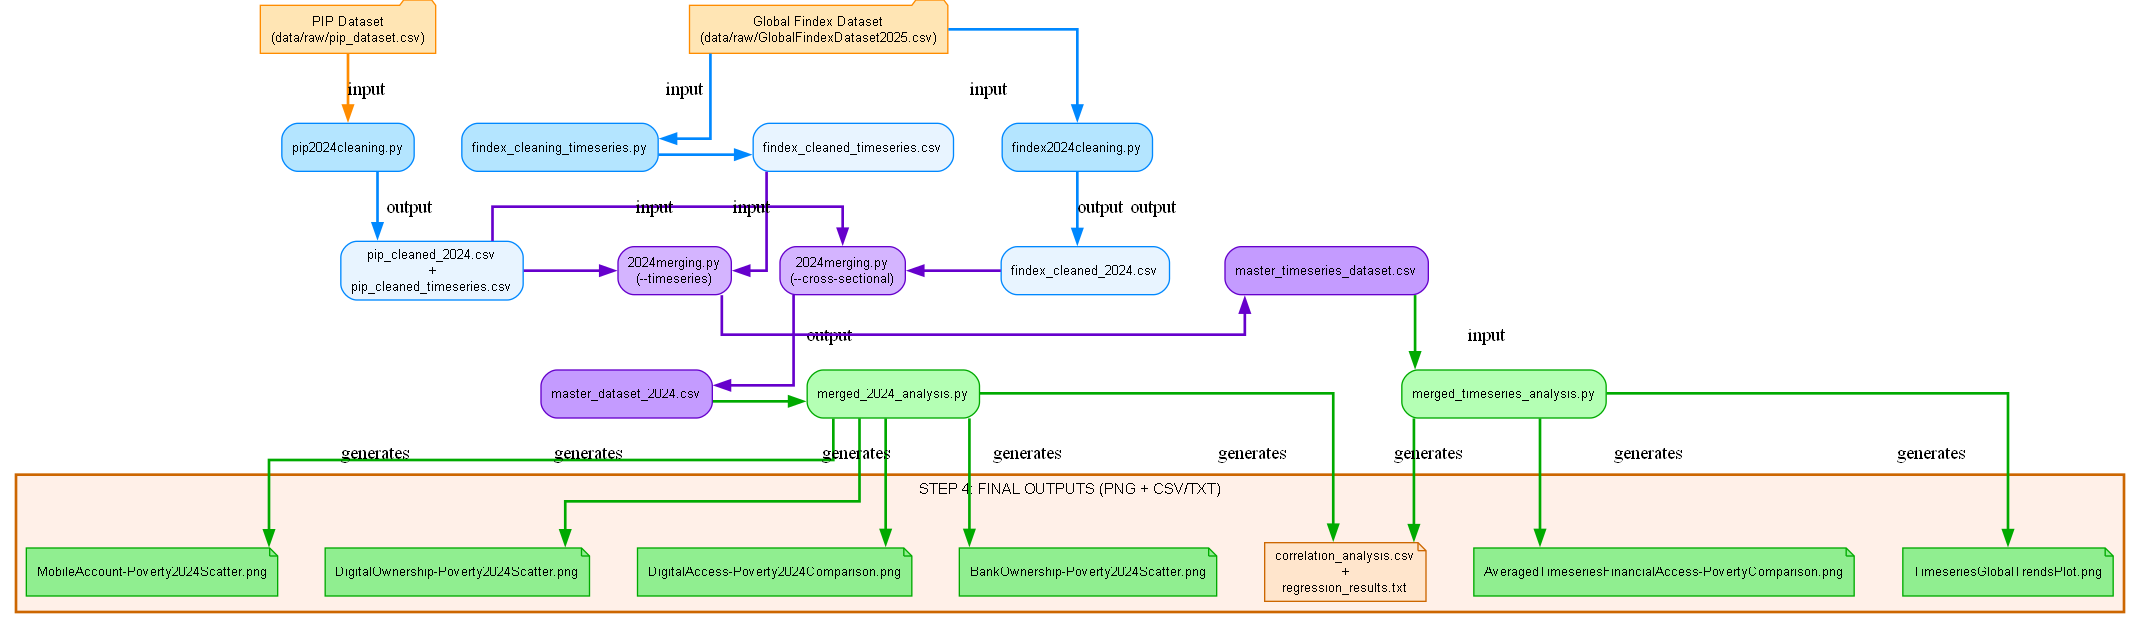


FLOW EXPLANATION

STAGE 1 - DATA CLEANING:
  • pip_dataset.csv → pip2024cleaning.py → pip_cleaned_2024.csv & pip_cleaned_timeseries.csv
  • GlobalFindexDataset2025.csv → findex2024cleaning.py → findex_cleaned_2024.csv
  • GlobalFindexDataset2025.csv → findex_cleaning_timeseries.py → findex_cleaned_timeseries.csv

STAGE 2 - DATA MERGING:
  • pip_cleaned_2024.csv + findex_cleaned_2024.csv → 2024merging.py → master_dataset_2024.csv
  • pip_cleaned_timeseries.csv + findex_cleaned_timeseries.csv → 2024merging.py → master_timeseries_dataset.csv

STAGE 3 - ANALYSIS:
  • master_dataset_2024.csv → merged_2024_analysis.py → 4 scatter plots + correlation_analysis.csv
  • master_timeseries_dataset.csv → merged_timeseries_analysis.py → 2 trend plots + regression_results.txt

STAGE 4 - FINAL OUTPUTS:
  • 6 PNG figures + 2 data files (correlation_analysis.csv, regression_results.txt)



In [17]:
# Clean DAG Generator - Shows clear data flow from inputs to outputs

import graphviz
import os

def create_flowchart_dag():
    """Create a clean flowchart showing the data pipeline"""
    
    dot = """digraph PipelineFlowchart {
    rankdir=TB;
    nodesep=0.5;
    ranksep=0.5;
    splines=ortho;
    fontname="Arial";
    fontsize=11;
    compound=true;
    
    // Node styles
    node [shape=box, style="rounded,filled", fontname="Arial", fontsize=10];
    edge [penwidth=2];
    
    // ============================================================
    // RAW INPUT FILES (Top)
    // ============================================================
    node [shape=folder, fillcolor="#FFE5B4", color="#FF8C00"];
    pip_raw [label="PIP Dataset\\n(data/raw/pip_dataset.csv)"];
    findex_raw [label="Global Findex Dataset\\n(data/raw/GlobalFindexDataset2025.csv)"];
    
    // ============================================================
    // CLEANING SCRIPTS & OUTPUTS
    // ============================================================
    node [shape=box, fillcolor="#B4E5FF", color="#0088FF"];
    clean_pip [label="pip2024cleaning.py"];
    clean_findex [label="findex2024cleaning.py"];
    clean_findex_ts [label="findex_cleaning_timeseries.py"];
    
    node [shape=box, fillcolor="#E8F4FF", color="#0088FF"];
    pip_cleaned [label="pip_cleaned_2024.csv\\n+\\npip_cleaned_timeseries.csv"];
    findex_cleaned [label="findex_cleaned_2024.csv"];
    findex_cleaned_ts [label="findex_cleaned_timeseries.csv"];
    
    // ============================================================
    // MERGING SCRIPTS & OUTPUTS
    // ============================================================
    node [shape=box, fillcolor="#D4B4FF", color="#6600CC"];
    merge_2024 [label="2024merging.py\\n(--cross-sectional)"];
    merge_ts [label="2024merging.py\\n(--timeseries)"];
    
    node [shape=box, fillcolor="#C49BFF", color="#6600CC"];
    master_2024 [label="master_dataset_2024.csv"];
    master_ts [label="master_timeseries_dataset.csv"];
    
    // ============================================================
    // ANALYSIS SCRIPTS & OUTPUTS
    // ============================================================
    node [shape=box, fillcolor="#B4FFB4", color="#00AA00"];
    analyze_2024 [label="merged_2024_analysis.py"];
    analyze_ts [label="merged_timeseries_analysis.py"];
    
    // ============================================================
    // FINAL OUTPUTS (Bottom)
    // ============================================================
    node [shape=note, fillcolor="#90EE90", color="#00AA00"];
    output1 [label="BankOwnership-Poverty2024Scatter.png"];
    output2 [label="MobileAccount-Poverty2024Scatter.png"];
    output3 [label="DigitalOwnership-Poverty2024Scatter.png"];
    output4 [label="DigitalAccess-Poverty2024Comparison.png"];
    
    node [shape=note, fillcolor="#90EE90", color="#00AA00"];
    output5 [label="TimeseriesGlobalTrendsPlot.png"];
    output6 [label="AveragedTimeseriesFinancialAccess-PovertyComparison.png"];
    
    node [shape=note, fillcolor="#FFE5CC", color="#CC6600"];
    output_stats [label="correlation_analysis.csv\\n+\\nregression_results.txt"];
    
    // ============================================================
    // DATA FLOW ARROWS
    // ============================================================
    
    // Stage 1: Raw -> Cleaning Scripts
    pip_raw -> clean_pip [color="#FF8C00", label="input"];
    findex_raw -> clean_findex [color="#0088FF", label="input"];
    findex_raw -> clean_findex_ts [color="#0088FF", label="input"];
    
    // Stage 2: Cleaning Scripts -> Cleaned Files
    clean_pip -> pip_cleaned [color="#0088FF", label="output"];
    clean_findex -> findex_cleaned [color="#0088FF", label="output"];
    clean_findex_ts -> findex_cleaned_ts [color="#0088FF", label="output"];
    
    // Stage 3: Cleaned Files -> Merge Scripts
    pip_cleaned -> merge_2024 [color="#6600CC", label="input"];
    findex_cleaned -> merge_2024 [color="#6600CC", label="input"];
    pip_cleaned -> merge_ts [color="#6600CC", label="input"];
    findex_cleaned_ts -> merge_ts [color="#6600CC", label="input"];
    
    // Stage 4: Merge Scripts -> Master Files
    merge_2024 -> master_2024 [color="#6600CC", label="output"];
    merge_ts -> master_ts [color="#6600CC", label="output"];
    
    // Stage 5: Master Files -> Analysis Scripts
    master_2024 -> analyze_2024 [color="#00AA00", label="input"];
    master_ts -> analyze_ts [color="#00AA00", label="input"];
    
    // Stage 6: Analysis Scripts -> Final Outputs
    analyze_2024 -> output1 [color="#00AA00", label="generates"];
    analyze_2024 -> output2 [color="#00AA00", label="generates"];
    analyze_2024 -> output3 [color="#00AA00", label="generates"];
    analyze_2024 -> output4 [color="#00AA00", label="generates"];
    analyze_2024 -> output_stats [color="#00AA00", label="generates"];
    
    analyze_ts -> output5 [color="#00AA00", label="generates"];
    analyze_ts -> output6 [color="#00AA00", label="generates"];
    analyze_ts -> output_stats [color="#00AA00", label="generates"];
    
    // ============================================================
    // CLUSTERS FOR VISUAL ORGANIZATION
    // ============================================================
    subgraph cluster_raw {
        label="INPUT DATA (Raw Files)";
        style=filled;
        fillcolor="#FFF8F0";
        color="#FF8C00";
        penwidth=2;
        pip_raw;
        findex_raw;
    }
    
    subgraph cluster_cleaning {
        label="STEP 1: DATA CLEANING";
        style=filled;
        fillcolor="#E8F4FF";
        color="#0088FF";
        penwidth=2;
        clean_pip;
        clean_findex;
        clean_findex_ts;
        pip_cleaned;
        findex_cleaned;
        findex_cleaned_ts;
    }
    
    subgraph cluster_merging {
        label="STEP 2: DATA MERGING";
        style=filled;
        fillcolor="#F0E8FF";
        color="#6600CC";
        penwidth=2;
        merge_2024;
        merge_ts;
        master_2024;
        master_ts;
    }
    
    subgraph cluster_analysis {
        label="STEP 3: ANALYSIS";
        style=filled;
        fillcolor="#E8FFE8";
        color="#00AA00";
        penwidth=2;
        analyze_2024;
        analyze_ts;
    }
    
    subgraph cluster_outputs {
        label="STEP 4: FINAL OUTPUTS (PNG + CSV/TXT)";
        style=filled;
        fillcolor="#FFF0E8";
        color="#CC6600";
        penwidth=2;
        output1;
        output2;
        output3;
        output4;
        output5;
        output6;
        output_stats;
    }
    
    // Rank to force vertical layout
    { rank=same; pip_raw; findex_raw; }
    { rank=same; clean_pip; clean_findex; clean_findex_ts; }
    { rank=same; pip_cleaned; findex_cleaned; findex_cleaned_ts; }
    { rank=same; merge_2024; merge_ts; }
    { rank=same; master_2024; master_ts; }
    { rank=same; analyze_2024; analyze_ts; }
}"""
    
    return dot

# Main execution
print("="*80)
print("GENERATING PIPELINE FLOWCHART")
print("Shows: Raw Files → Scripts → Processed → Scripts → Final Outputs")
print("="*80)

try:
    # Create the DAG
    dot_code = create_flowchart_dag()
    
    # Save DOT file
    with open("pipeline_flowchart.dot", "w") as f:
        f.write(dot_code)
    
    # Render PNG
    graph = graphviz.Source(dot_code)
    output_path = graph.render("pipeline_flowchart", format="png", cleanup=True)
    
    print(f"\n✓ Flowchart generated: {output_path}")
    
    # Display the flowchart
    from IPython.display import Image, display
    print("\n" + "="*80)
    print("PIPELINE DATA FLOW DIAGRAM")
    print("Arrows show file → script → file flow through each stage")
    print("="*80 + "\n")
    display(Image("pipeline_flowchart.png"))
    
    # Print explanation
    print("\n" + "="*80)
    print("FLOW EXPLANATION")
    print("="*80)
    print("""
STAGE 1 - DATA CLEANING:
  • pip_dataset.csv → pip2024cleaning.py → pip_cleaned_2024.csv & pip_cleaned_timeseries.csv
  • GlobalFindexDataset2025.csv → findex2024cleaning.py → findex_cleaned_2024.csv
  • GlobalFindexDataset2025.csv → findex_cleaning_timeseries.py → findex_cleaned_timeseries.csv

STAGE 2 - DATA MERGING:
  • pip_cleaned_2024.csv + findex_cleaned_2024.csv → 2024merging.py → master_dataset_2024.csv
  • pip_cleaned_timeseries.csv + findex_cleaned_timeseries.csv → 2024merging.py → master_timeseries_dataset.csv

STAGE 3 - ANALYSIS:
  • master_dataset_2024.csv → merged_2024_analysis.py → 4 scatter plots + correlation_analysis.csv
  • master_timeseries_dataset.csv → merged_timeseries_analysis.py → 2 trend plots + regression_results.txt

STAGE 4 - FINAL OUTPUTS:
  • 6 PNG figures + 2 data files (correlation_analysis.csv, regression_results.txt)
""")
    print("="*80)
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()
    print("\nPlease ensure graphviz is installed:")
    print("  conda install graphviz")
    print("  OR")
    print("  pip install graphviz")